# Yeni Araç Verisi — Tahmin ve Analiz Notebook'u
**Girdi:** `yeni_arabalar_temiz.xlsx` (VeriTemizleme_Yeni.ipynb çıktısı)  
**Model:** Eğitilmiş `ensemble_rf_gb_best.pkl` (RF + GB %50-%50)  
**İçerik:** Model performansı, hata analizi, segment karşılaştırması, özellik önemi — 10 grafik

## 1. Kütüphaneler

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import category_encoders as ce

# Grafik stili
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

RENK_ENS  = '#E8604C'   # Ensemble — kırmızı-turuncu
RENK_RF   = '#4878CF'   # Random Forest — mavi
RENK_GB   = '#C4AD66'   # Gradient Boosting — altın
RENK_KOYUMAVI = '#1A2B4A'

print('Kütüphaneler yüklendi ✅')

Kütüphaneler yüklendi ✅


## 2. Veri Yükleme

In [3]:
# Temiz yeni veri
df_yeni = pd.read_excel('yeni_araba_126_adet.xlsx')
print(f'Yeni veri: {df_yeni.shape[0]} satır, {df_yeni.shape[1]} sütun')

# Eğitim verisi (feature engineering ve encoding için referans)
df_egitim = pd.read_excel('verisetiTemiz.xlsx')
print(f'Eğitim verisi: {df_egitim.shape[0]} satır')

df_yeni.head()

Yeni veri: 126 satır, 21 sütun
Eğitim verisi: 48258 satır


,marka,model,kilometre,vites_tipi,yakit_tipi,kasa_tipi,renk,motor_hacmi,motor_gucu,cekis,...,tramer,boyali_sayisi,degisen_sayisi,tramer_bilinmiyor,tramer_kategori,sehir,ilan_yil,ilan_ay,yas,fiyat
0,Hyundai_i20,diger,127000,Otomatik,Benzin,Hatchback/5,Beyaz,1300,88,Önden Çekiş,...,9200,5,0,0,orta,Kahramanmaraş,2026,5,6,1090000
1,BMW_1 Serisi,diger,93000,Otomatik,Benzin,Hatchback/5,Beyaz,1500,136,Arkadan İtiş,...,0,1,1,0,yok,Isparta,2026,5,9,1415000
2,Toyota_Corolla,1.33 Life,180000,Düz,LPG & Benzin,Sedan,Füme,1300,88,Önden Çekiş,...,0,1,0,0,yok,Kütahya,2026,5,10,925000
3,Volkswagen_Passat,1.6 TDi BlueMotion Comfortline,93000,Düz,Dizel,Sedan,Gri,1600,120,Önden Çekiş,...,0,0,0,0,yok,Afyonkarahisar,2026,5,9,1719750
4,Volkswagen_Polo,diger,180000,Yarı Otomatik,Dizel,Hatchback/5,Gri,1400,90,Önden Çekiş,...,0,4,0,0,yok,Ankara,2026,5,9,915000


## 3. Feature Engineering (Eğitim Pipeline ile Aynı)

In [5]:
def feature_engineering(df):
    df = df.copy()
    df['km_per_year']      = df['kilometre'] / (df['yas'] + 1)
    df['motor_verimlilik'] = df['motor_gucu'] / (df['motor_hacmi'] + 1)
    df['hasar_skoru']      = df['boyali_sayisi'] + df['degisen_sayisi'] * 2 + df['tramer'] / 1000
    df['log_km']           = np.log1p(df['kilometre'])
    df['motor_gucu_sq']    = df['motor_gucu'] ** 2
    return df

df_yeni = feature_engineering(df_yeni)
df_egitim = feature_engineering(df_egitim)
print('Feature engineering tamamlandı ✅')
print('Yeni özellikler:', ['km_per_year','motor_verimlilik','hasar_skoru','log_km','motor_gucu_sq'])

Feature engineering tamamlandı ✅
Yeni özellikler: ['km_per_year', 'motor_verimlilik', 'hasar_skoru', 'log_km', 'motor_gucu_sq']


## 4. Encoding + Model Eğitimi
Eğitim verisiyle encoder fit edilir, yeni veriye transform uygulanır.

In [7]:
LOW_CARD  = ['vites_tipi', 'yakit_tipi', 'kasa_tipi', 'renk', 'cekis', 'kimden', 'tramer_kategori']
HIGH_CARD = ['marka', 'model', 'sehir']

# ── Eğitim verisi hazırlık ──────────────────────────────────────────────────
X_train = df_egitim.drop(columns=['fiyat'])
y_train = df_egitim['fiyat']
y_train_log = np.log1p(y_train)

# One-Hot Encoding (eğitim)
X_train_ohe = pd.get_dummies(X_train, columns=LOW_CARD, drop_first=True)

# Target Encoding (eğitim)
enc = ce.TargetEncoder(cols=HIGH_CARD)
X_train_ohe[HIGH_CARD] = enc.fit_transform(X_train_ohe[HIGH_CARD], y_train_log)

# ── Yeni veri hazırlık ──────────────────────────────────────────────────────
X_yeni = df_yeni.drop(columns=['fiyat'])
y_yeni = df_yeni['fiyat']

# One-Hot Encoding (yeni)
X_yeni_ohe = pd.get_dummies(X_yeni, columns=LOW_CARD, drop_first=True)

# Eğitim sütunlarıyla hizala
X_yeni_ohe = X_yeni_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

# Target Encoding (yeni — fit edilmiş encoder kullanılır)
X_yeni_ohe[HIGH_CARD] = enc.transform(X_yeni_ohe[HIGH_CARD])

print(f'Eğitim özellikleri: {X_train_ohe.shape}')
print(f'Yeni veri özellikleri: {X_yeni_ohe.shape}')

Eğitim özellikleri: (48258, 55)
Yeni veri özellikleri: (126, 55)


In [57]:
# ── Modelleri Eğit ─────────────────────────────────────────────────────────
print('Modeller eğitiliyor...')

rf = RandomForestRegressor(
    n_estimators=80, max_features=0.5, max_samples=0.85,
    n_jobs=-1, random_state=42
)
rf.fit(X_train_ohe, y_train_log)
print('  ✅ Random Forest')

gb = GradientBoostingRegressor(
    n_estimators=150, max_depth=6, learning_rate=0.1,
    subsample=0.8, random_state=42
)
gb.fit(X_train_ohe, y_train_log)
print('  ✅ Gradient Boosting')

print('Eğitim tamamlandı ✅')

Modeller eğitiliyor...
  ✅ Random Forest
  ✅ Gradient Boosting
Eğitim tamamlandı ✅


## 5. Yeni Veri Üzerinde Tahmin

In [59]:
# Tekil tahminler
pred_rf = np.expm1(rf.predict(X_yeni_ohe))
pred_gb = np.expm1(gb.predict(X_yeni_ohe))

# Ensemble (50-50)
pred_ens = pred_rf * 0.5 + pred_gb * 0.5

# Sonuç DataFrame
sonuclar = pd.DataFrame({
    'gercek_fiyat'  : y_yeni.values,
    'tahmin_rf'     : pred_rf,
    'tahmin_gb'     : pred_gb,
    'tahmin_ens'    : pred_ens,
    'hata_rf'       : np.abs(y_yeni.values - pred_rf),
    'hata_gb'       : np.abs(y_yeni.values - pred_gb),
    'hata_ens'      : np.abs(y_yeni.values - pred_ens),
    'hata_pct_ens'  : np.abs(y_yeni.values - pred_ens) / y_yeni.values * 100,
})

# Performans özeti
def metrikler(gercek, tahmin, isim):
    r2   = r2_score(gercek, tahmin)
    mae  = mean_absolute_error(gercek, tahmin)
    rmse = np.sqrt(mean_squared_error(gercek, tahmin))
    mape = np.mean(np.abs((gercek - tahmin) / gercek)) * 100
    print(f'{isim:20s}  R²={r2:.4f}  MAE={mae:>10,.0f} TL  RMSE={rmse:>10,.0f} TL  MAPE={mape:.2f}%')
    return dict(isim=isim, r2=r2, mae=mae, rmse=rmse, mape=mape)

print('─'*80)
met_rf  = metrikler(y_yeni.values, pred_rf,  'Random Forest')
met_gb  = metrikler(y_yeni.values, pred_gb,  'Gradient Boosting')
met_ens = metrikler(y_yeni.values, pred_ens, 'Ensemble RF+GB')
print('─'*80)
metriks = pd.DataFrame([met_rf, met_gb, met_ens])
metriks

────────────────────────────────────────────────────────────────────────────────
Random Forest         R²=0.8563  MAE=   149,444 TL  RMSE=   195,362 TL  MAPE=15.28%
Gradient Boosting     R²=0.8642  MAE=   143,114 TL  RMSE=   189,919 TL  MAPE=14.70%
Ensemble RF+GB        R²=0.8623  MAE=   145,754 TL  RMSE=   191,262 TL  MAPE=14.85%
────────────────────────────────────────────────────────────────────────────────


,isim,r2,mae,rmse,mape
0,Random Forest,0.856326,149443.530368,195362.276983,15.280790
1,Gradient Boosting,0.864221,143114.364314,189919.018489,14.701206
2,Ensemble RF+GB,0.862294,145754.363747,191261.629348,14.851889


## 6. Grafik 1 — Gerçek Fiyat vs Tahmin (Scatter)

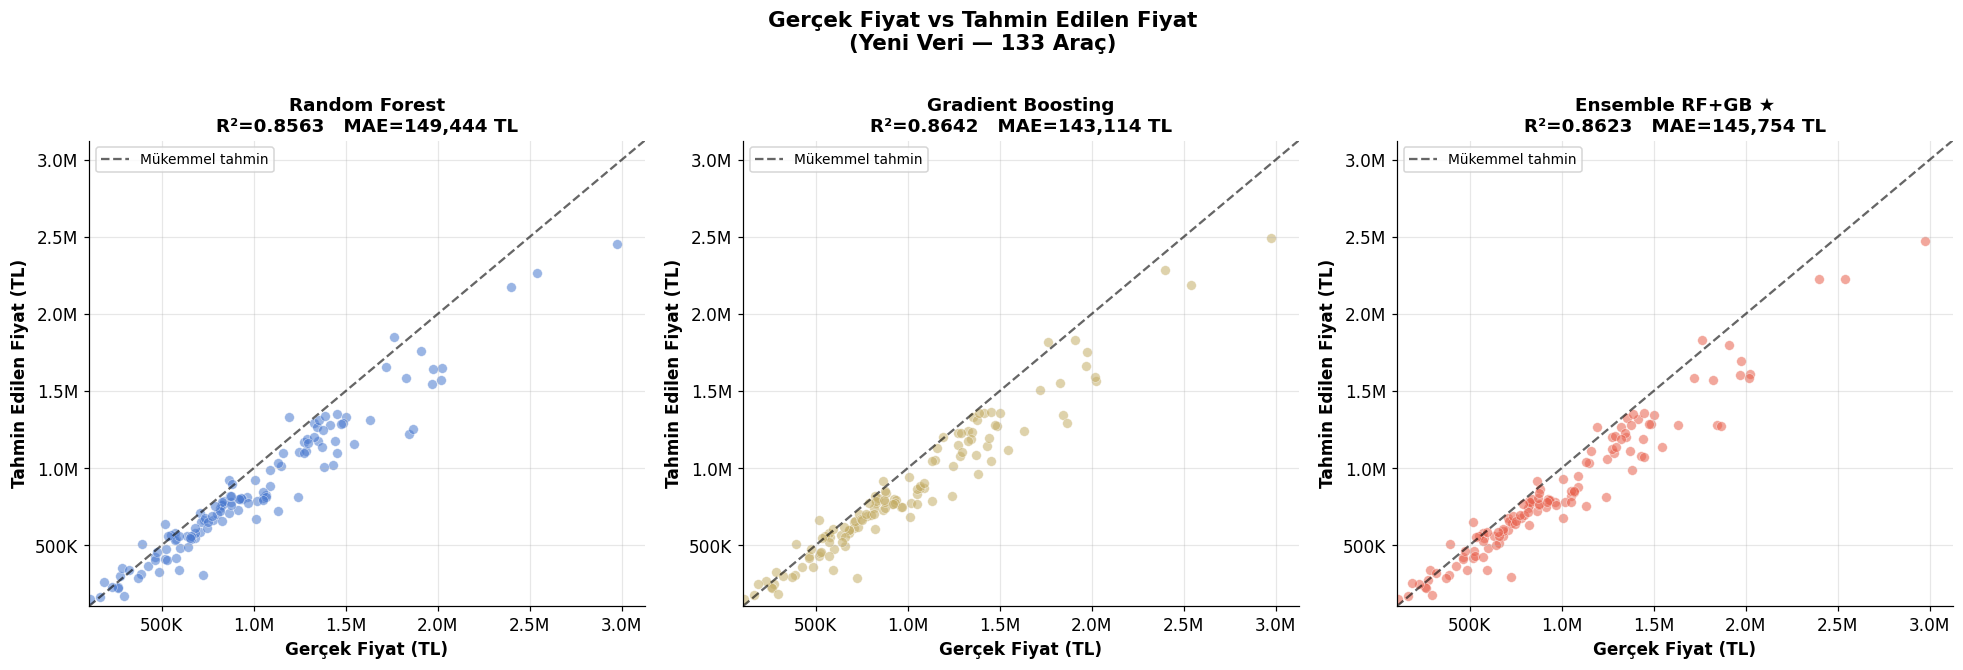

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
modeller = [
    ('Random Forest', pred_rf,  RENK_RF),
    ('Gradient Boosting', pred_gb, RENK_GB),
    ('Ensemble RF+GB ★', pred_ens, RENK_ENS),
]

for ax, (isim, pred, renk) in zip(axes, modeller):
    lim = [min(y_yeni.min(), pred.min()) * 0.95,
           max(y_yeni.max(), pred.max()) * 1.05]
    ax.scatter(y_yeni, pred, alpha=0.55, s=40, color=renk, edgecolors='white', linewidths=0.4)
    ax.plot(lim, lim, 'k--', lw=1.5, alpha=0.6, label='Mükemmel tahmin')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Gerçek Fiyat (TL)', fontweight='bold')
    ax.set_ylabel('Tahmin Edilen Fiyat (TL)', fontweight='bold')
    r2  = r2_score(y_yeni, pred)
    mae = mean_absolute_error(y_yeni, pred)
    ax.set_title(f'{isim}\nR²={r2:.4f}   MAE={mae:,.0f} TL', fontweight='bold', fontsize=12)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M' if x>=1e6 else f'{int(x/1e3)}K'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M' if x>=1e6 else f'{int(x/1e3)}K'))
    ax.legend(fontsize=9)

fig.suptitle('Gerçek Fiyat vs Tahmin Edilen Fiyat\n(Yeni Veri — 133 Araç)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('grafik1_scatter.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Grafik 2 — R² ve MAE Karşılaştırması (Yan Yana)

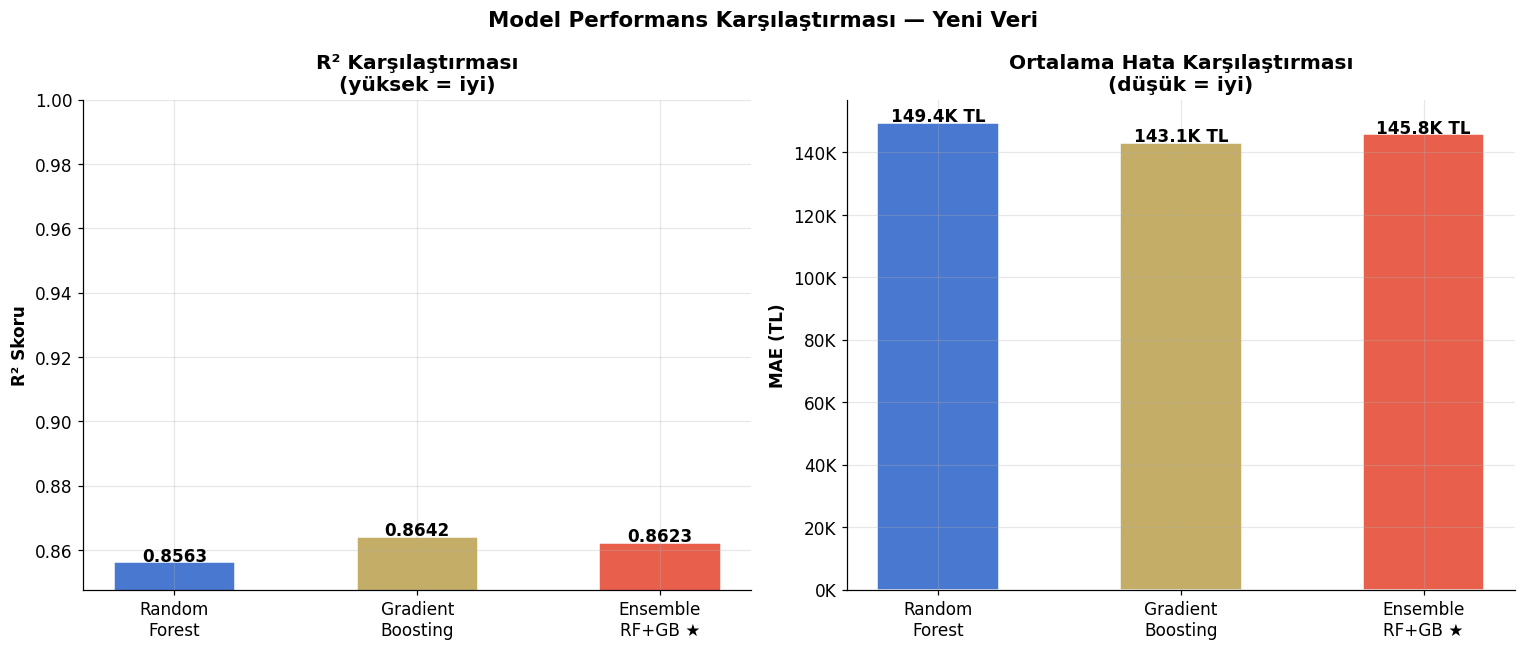

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

isimler = ['Random\nForest', 'Gradient\nBoosting', 'Ensemble\nRF+GB ★']
r2_deger  = [met_rf['r2'],  met_gb['r2'],  met_ens['r2']]
mae_deger = [met_rf['mae'], met_gb['mae'], met_ens['mae']]
renkler   = [RENK_RF, RENK_GB, RENK_ENS]

# R² Bar
bars = ax1.bar(isimler, r2_deger, color=renkler, edgecolor='white', linewidth=1, width=0.5)
ax1.set_ylim(min(r2_deger) * 0.99, 1.0)
ax1.set_ylabel('R² Skoru', fontweight='bold')
ax1.set_title('R² Karşılaştırması\n(yüksek = iyi)', fontweight='bold')
for bar, val in zip(bars, r2_deger):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

# MAE Bar
bars2 = ax2.bar(isimler, mae_deger, color=renkler, edgecolor='white', linewidth=1, width=0.5)
ax2.set_ylabel('MAE (TL)', fontweight='bold')
ax2.set_title('Ortalama Hata Karşılaştırması\n(düşük = iyi)', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
for bar, val in zip(bars2, mae_deger):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val/1000:.1f}K TL', ha='center', fontweight='bold', fontsize=11)

fig.suptitle('Model Performans Karşılaştırması — Yeni Veri', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik2_karsilastirma.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Grafik 3 — Hata Dağılımı (Histogram + KDE)

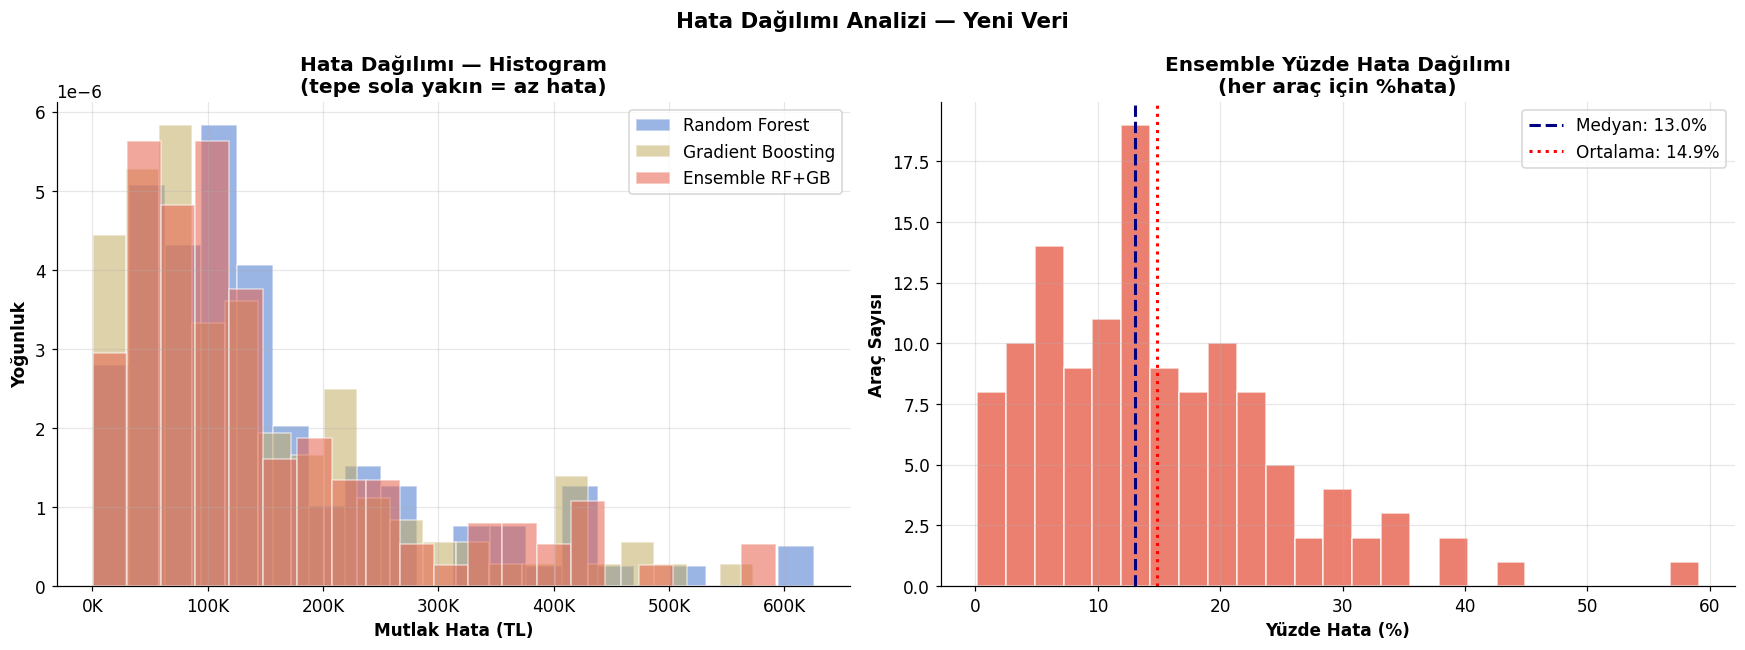

In [68]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Mutlak hata histogram
for label, hatalar, renk in [
    ('Random Forest',    sonuclar['hata_rf'],  RENK_RF),
    ('Gradient Boosting',sonuclar['hata_gb'],  RENK_GB),
    ('Ensemble RF+GB',   sonuclar['hata_ens'], RENK_ENS),
]:
    ax1.hist(hatalar, bins=20, alpha=0.55, color=renk, label=label, density=True, edgecolor='white')

ax1.set_xlabel('Mutlak Hata (TL)', fontweight='bold')
ax1.set_ylabel('Yoğunluk', fontweight='bold')
ax1.set_title('Hata Dağılımı — Histogram\n(tepe sola yakın = az hata)', fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
ax1.legend()

# Yüzde hata (Ensemble)
ax2.hist(sonuclar['hata_pct_ens'], bins=25, color=RENK_ENS, alpha=0.8, edgecolor='white')
medyan = sonuclar['hata_pct_ens'].median()
ort    = sonuclar['hata_pct_ens'].mean()
ax2.axvline(medyan, color='navy', linestyle='--', linewidth=2, label=f'Medyan: {medyan:.1f}%')
ax2.axvline(ort,    color='red',  linestyle=':',  linewidth=2, label=f'Ortalama: {ort:.1f}%')
ax2.set_xlabel('Yüzde Hata (%)', fontweight='bold')
ax2.set_ylabel('Araç Sayısı', fontweight='bold')
ax2.set_title('Ensemble Yüzde Hata Dağılımı\n(her araç için %hata)', fontweight='bold')
ax2.legend()

fig.suptitle('Hata Dağılımı Analizi — Yeni Veri', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik3_hata_dagilim.png', dpi=130, bbox_inches='tight')
plt.show()

## 9. Grafik 4 — Fiyat Dilimlerine Göre MAE

    Dilim  Araç Sayısı        MAE RF        MAE GB       MAE ENS  MAPE ENS
   0-300K            9  45233.479339  46256.261988  43168.714582 19.595797
 300-600K           22  78688.119873  72114.834830  74079.579213 14.752260
 600-900K           34  96095.272960  90743.380452  93012.551146 12.407699
900K-1.2M           22 183408.971324 174480.530857 178944.751090 17.374440
    1.2M+           39 240754.057062 233480.270902 237117.163982 14.521197


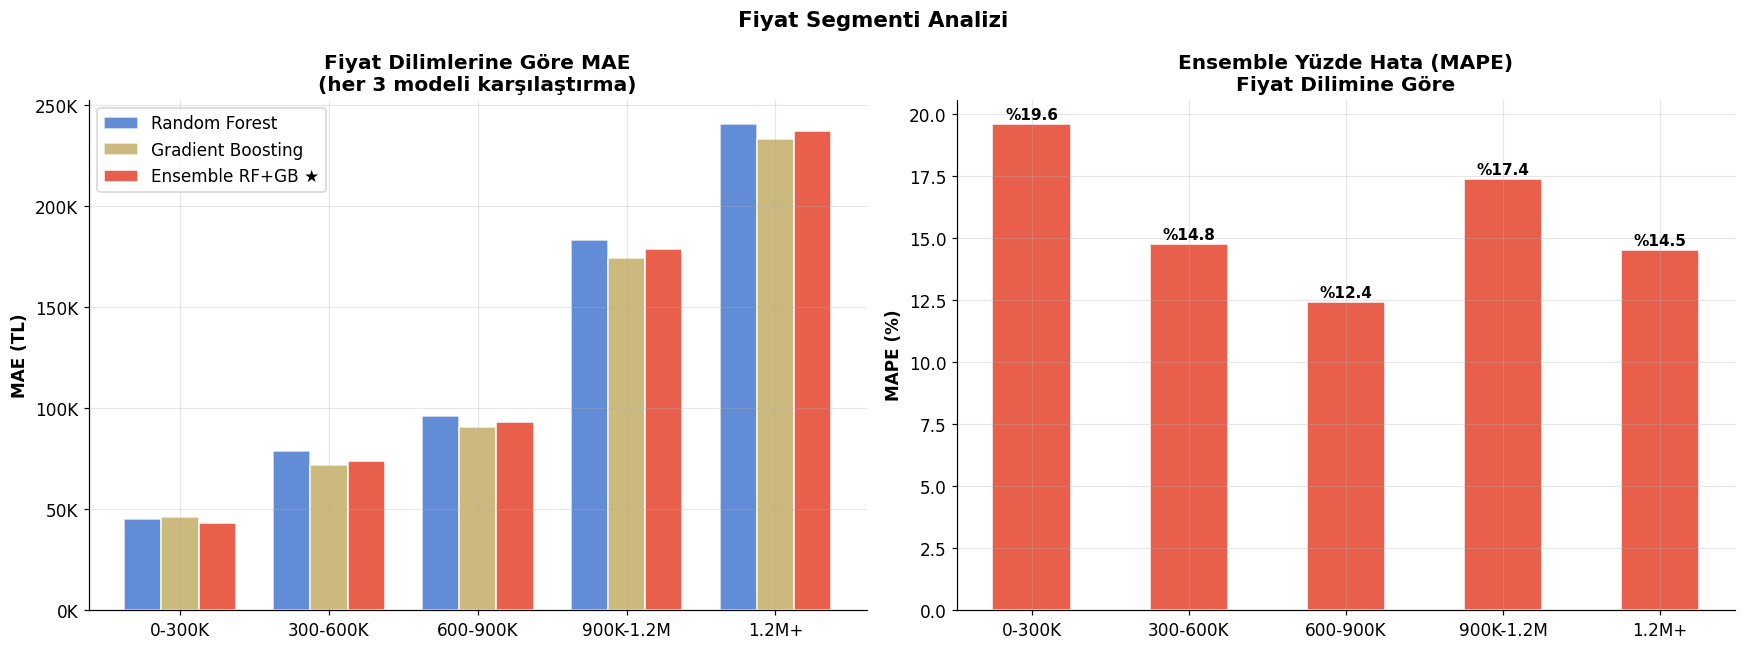

In [70]:
DILIMLER = [
    ('0-300K',    (sonuclar['gercek_fiyat'] <= 300_000)),
    ('300-600K',  (sonuclar['gercek_fiyat'] > 300_000) & (sonuclar['gercek_fiyat'] <= 600_000)),
    ('600-900K',  (sonuclar['gercek_fiyat'] > 600_000) & (sonuclar['gercek_fiyat'] <= 900_000)),
    ('900K-1.2M', (sonuclar['gercek_fiyat'] > 900_000) & (sonuclar['gercek_fiyat'] <= 1_200_000)),
    ('1.2M+',     (sonuclar['gercek_fiyat'] > 1_200_000)),
]

dilim_sonuc = []
for ad, mask in DILIMLER:
    alt = sonuclar[mask]
    if len(alt) == 0:
        continue
    dilim_sonuc.append({
        'Dilim': ad,
        'Araç Sayısı': len(alt),
        'MAE RF': alt['hata_rf'].mean(),
        'MAE GB': alt['hata_gb'].mean(),
        'MAE ENS': alt['hata_ens'].mean(),
        'MAPE ENS': (alt['hata_ens'] / alt['gercek_fiyat'] * 100).mean(),
    })

df_dilim = pd.DataFrame(dilim_sonuc)
print(df_dilim.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(df_dilim))
w = 0.25
ax1.bar(x - w, df_dilim['MAE RF'],  w, label='Random Forest',    color=RENK_RF,  edgecolor='white', alpha=0.85)
ax1.bar(x,     df_dilim['MAE GB'],  w, label='Gradient Boosting', color=RENK_GB,  edgecolor='white', alpha=0.85)
ax1.bar(x + w, df_dilim['MAE ENS'], w, label='Ensemble RF+GB ★', color=RENK_ENS, edgecolor='white', alpha=1.0)
ax1.set_xticks(x); ax1.set_xticklabels(df_dilim['Dilim'])
ax1.set_ylabel('MAE (TL)', fontweight='bold')
ax1.set_title('Fiyat Dilimlerine Göre MAE\n(her 3 modeli karşılaştırma)', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
ax1.legend()

# MAPE bar
barlar = ax2.bar(df_dilim['Dilim'], df_dilim['MAPE ENS'], color=RENK_ENS, edgecolor='white', width=0.5)
for bar, val in zip(barlar, df_dilim['MAPE ENS']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'%{val:.1f}', ha='center', fontweight='bold', fontsize=10)
ax2.set_ylabel('MAPE (%)', fontweight='bold')
ax2.set_title('Ensemble Yüzde Hata (MAPE)\nFiyat Dilimine Göre', fontweight='bold')

fig.suptitle('Fiyat Segmenti Analizi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik4_segment.png', dpi=130, bbox_inches='tight')
plt.show()

## 10. Grafik 5 — Hata Isı Haritası (Tahmin Farkı)

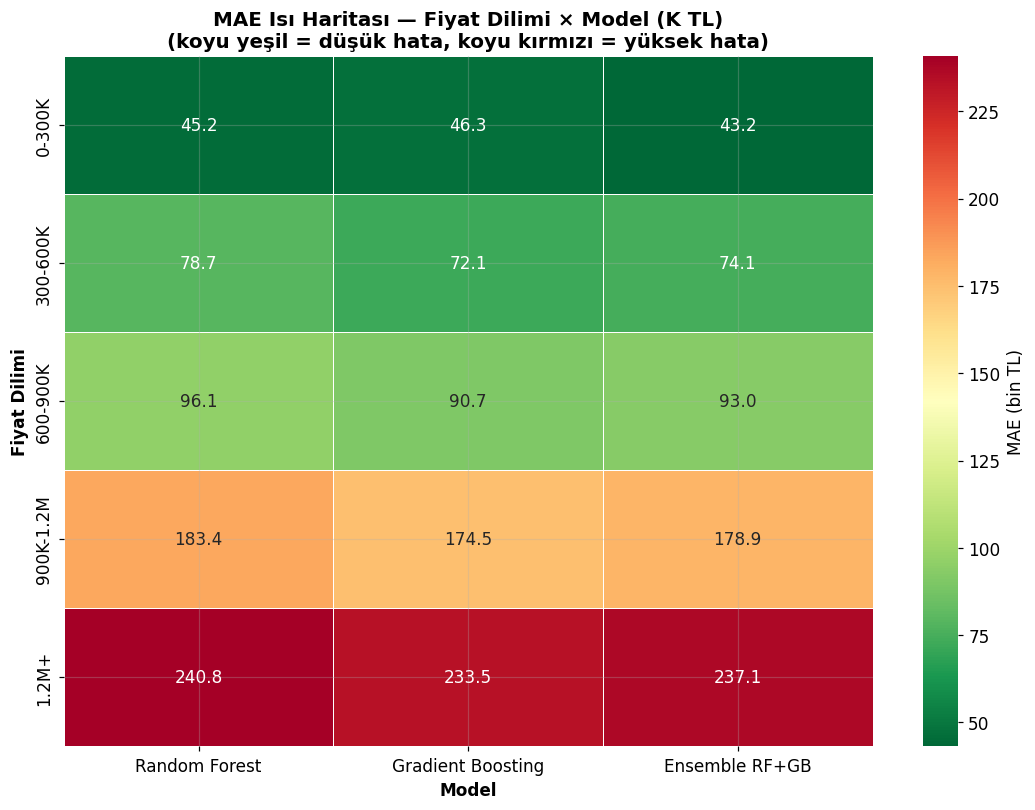

In [73]:
# Her model için her dilimde MAE matrisi
mat = {}
for ad, mask in DILIMLER:
    alt = sonuclar[mask]
    if len(alt) == 0:
        continue
    mat[ad] = {
        'Random Forest':    alt['hata_rf'].mean() / 1000,
        'Gradient Boosting':alt['hata_gb'].mean() / 1000,
        'Ensemble RF+GB':   alt['hata_ens'].mean() / 1000,
    }

df_mat = pd.DataFrame(mat).T  # satır=dilim, sütun=model

fig, ax = plt.subplots(figsize=(10, len(df_mat) * 1.1 + 2))
sns.heatmap(
    df_mat, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'MAE (bin TL)'}
)
ax.set_title('MAE Isı Haritası — Fiyat Dilimi × Model (K TL)\n(koyu yeşil = düşük hata, koyu kırmızı = yüksek hata)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Fiyat Dilimi', fontweight='bold')
plt.tight_layout()
plt.savefig('grafik5_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

## 11. Grafik 6 — Özellik Önemi (RF ve GB)

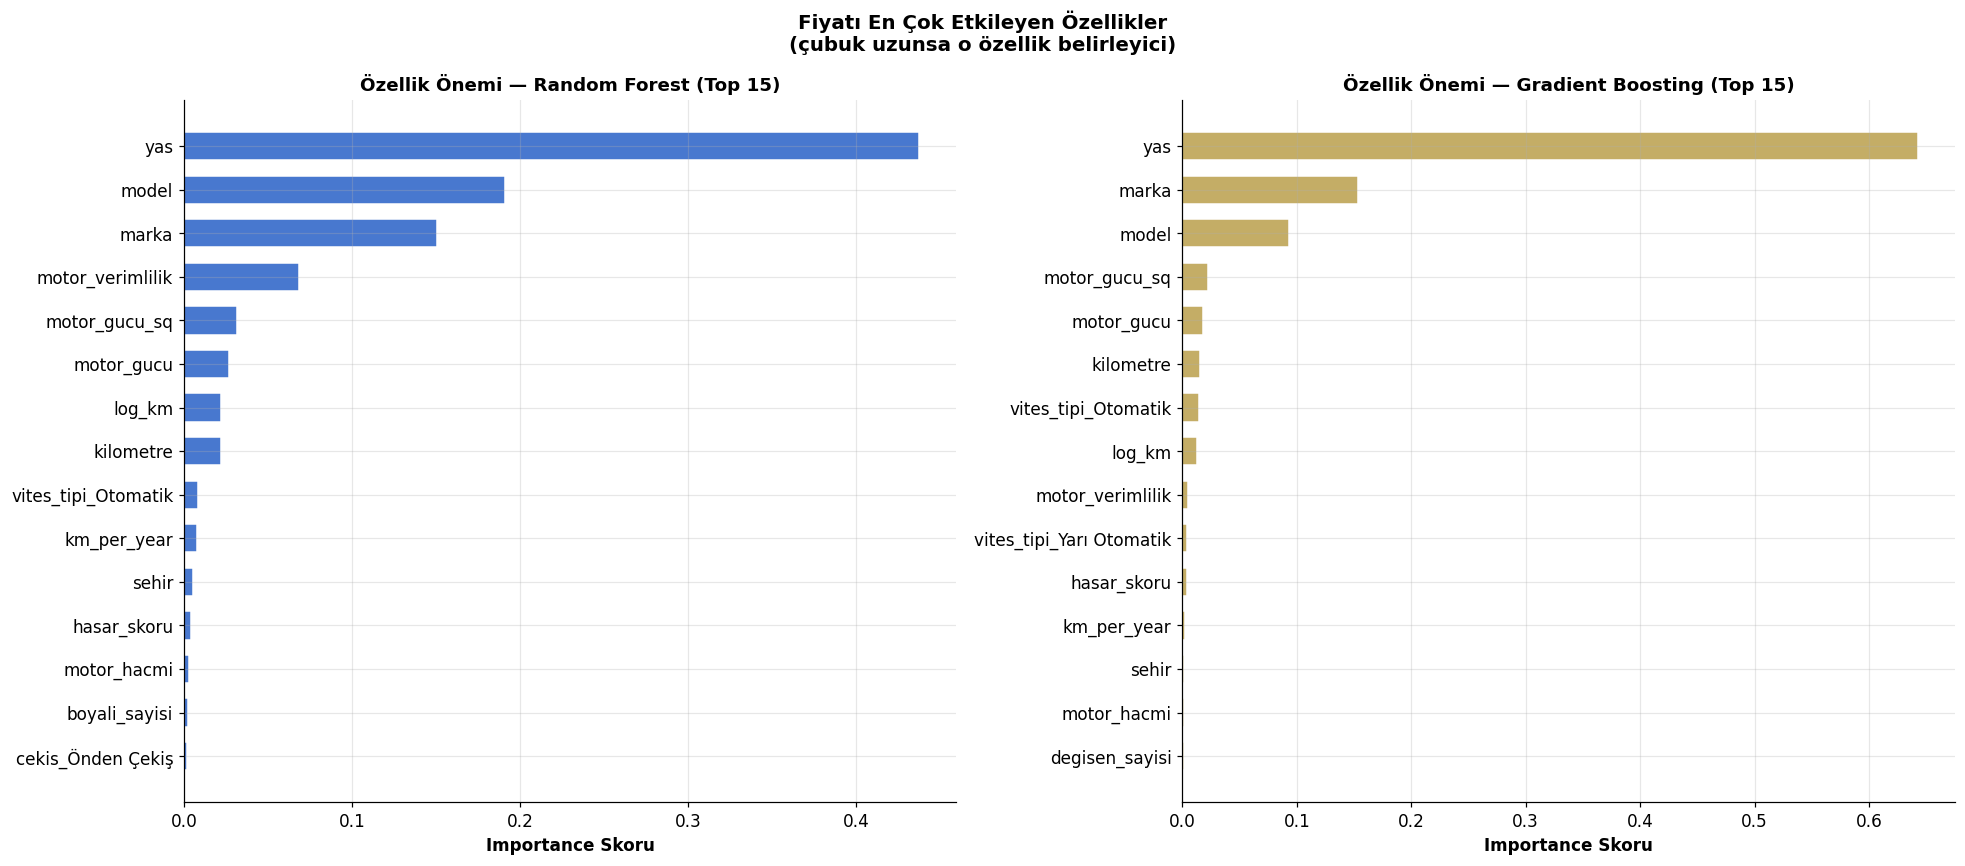

In [76]:
TOP = 15
rf_imp = pd.Series(rf.feature_importances_, index=X_train_ohe.columns).nlargest(TOP).sort_values()
gb_imp = pd.Series(gb.feature_importances_, index=X_train_ohe.columns).nlargest(TOP).sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.barh(rf_imp.index, rf_imp.values, color=RENK_RF, edgecolor='white', height=0.65)
ax1.set_title(f'Özellik Önemi — Random Forest (Top {TOP})', fontweight='bold', fontsize=12)
ax1.set_xlabel('Importance Skoru', fontweight='bold')

ax2.barh(gb_imp.index, gb_imp.values, color=RENK_GB, edgecolor='white', height=0.65)
ax2.set_title(f'Özellik Önemi — Gradient Boosting (Top {TOP})', fontweight='bold', fontsize=12)
ax2.set_xlabel('Importance Skoru', fontweight='bold')

fig.suptitle('Fiyatı En Çok Etkileyen Özellikler\n(çubuk uzunsa o özellik belirleyici)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik6_ozellik_onemi.png', dpi=130, bbox_inches='tight')
plt.show()

## 12. Grafik 7 — Tahmin Hatası vs Araç Yaşı

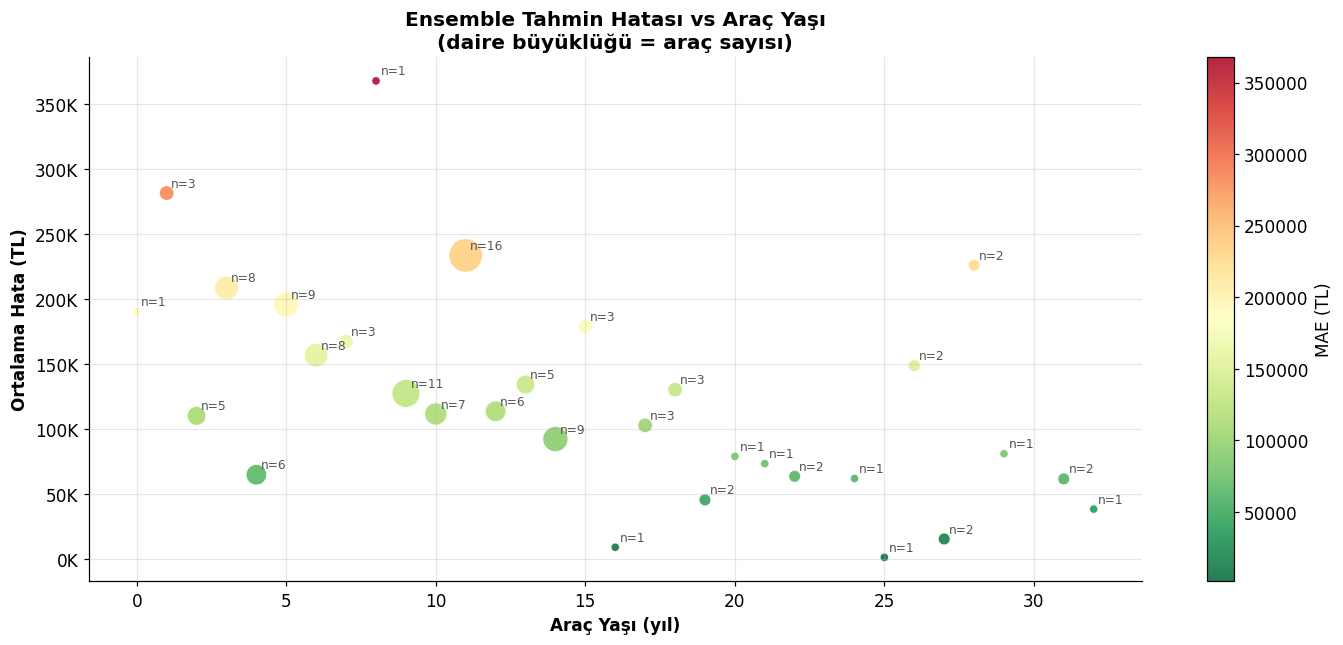

In [79]:
sonuclar_ext = sonuclar.copy()
sonuclar_ext['yas'] = df_yeni['yas'].values

yas_gruplari = sonuclar_ext.groupby('yas').agg(
    mae_ens=('hata_ens', 'mean'),
    arac_sayisi=('gercek_fiyat', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(13, 6))
scatter = ax.scatter(
    yas_gruplari['yas'], yas_gruplari['mae_ens'],
    s=yas_gruplari['arac_sayisi'] * 30,
    c=yas_gruplari['mae_ens'], cmap='RdYlGn_r',
    alpha=0.85, edgecolors='white', linewidths=0.5
)
plt.colorbar(scatter, ax=ax, label='MAE (TL)')

for _, row in yas_gruplari.iterrows():
    ax.annotate(f"n={int(row['arac_sayisi'])}",
                xy=(row['yas'], row['mae_ens']),
                xytext=(3, 4), textcoords='offset points',
                fontsize=8, color='#555555')

ax.set_xlabel('Araç Yaşı (yıl)', fontweight='bold')
ax.set_ylabel('Ortalama Hata (TL)', fontweight='bold')
ax.set_title('Ensemble Tahmin Hatası vs Araç Yaşı\n(daire büyüklüğü = araç sayısı)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
plt.tight_layout()
plt.savefig('grafik7_yas_hata.png', dpi=130, bbox_inches='tight')
plt.show()

## 13. Grafik 8 — Fiyat Tahmin Karşılaştırması (Araç Başına)

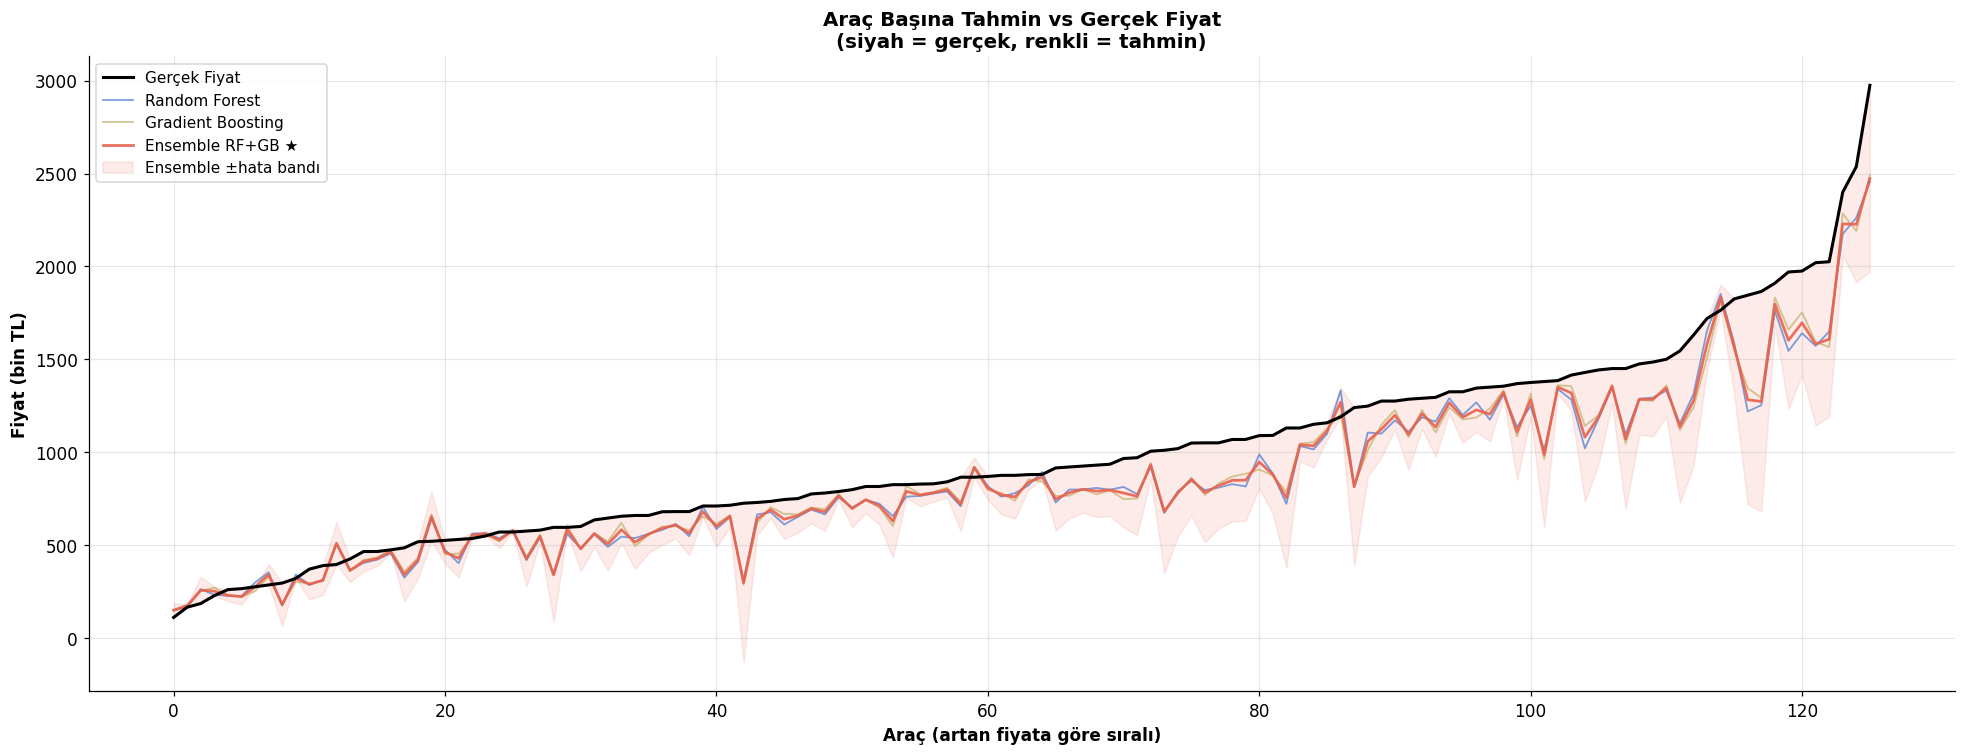

In [82]:
# Artan gerçek fiyata göre sırala
df_sirali = sonuclar.sort_values('gercek_fiyat').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(18, 7))
x = np.arange(len(df_sirali))

ax.plot(x, df_sirali['gercek_fiyat'] / 1000, 'k-', linewidth=2,   label='Gerçek Fiyat', zorder=5)
ax.plot(x, df_sirali['tahmin_rf']    / 1000, color=RENK_RF,  linewidth=1.2, alpha=0.7, label='Random Forest')
ax.plot(x, df_sirali['tahmin_gb']    / 1000, color=RENK_GB,  linewidth=1.2, alpha=0.7, label='Gradient Boosting')
ax.plot(x, df_sirali['tahmin_ens']   / 1000, color=RENK_ENS, linewidth=1.8, alpha=0.9, label='Ensemble RF+GB ★')

# Hata bantları (ensemble)
ax.fill_between(x,
    (df_sirali['tahmin_ens'] - df_sirali['hata_ens']) / 1000,
    (df_sirali['tahmin_ens'] + df_sirali['hata_ens']) / 1000,
    alpha=0.12, color=RENK_ENS, label='Ensemble ±hata bandı')

ax.set_xlabel('Araç (artan fiyata göre sıralı)', fontweight='bold')
ax.set_ylabel('Fiyat (bin TL)', fontweight='bold')
ax.set_title('Araç Başına Tahmin vs Gerçek Fiyat\n(siyah = gerçek, renkli = tahmin)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('grafik8_arac_tahmin.png', dpi=130, bbox_inches='tight')
plt.show()

## 14. Grafik 9 — En Çok / En Az Yanılan Araçlar

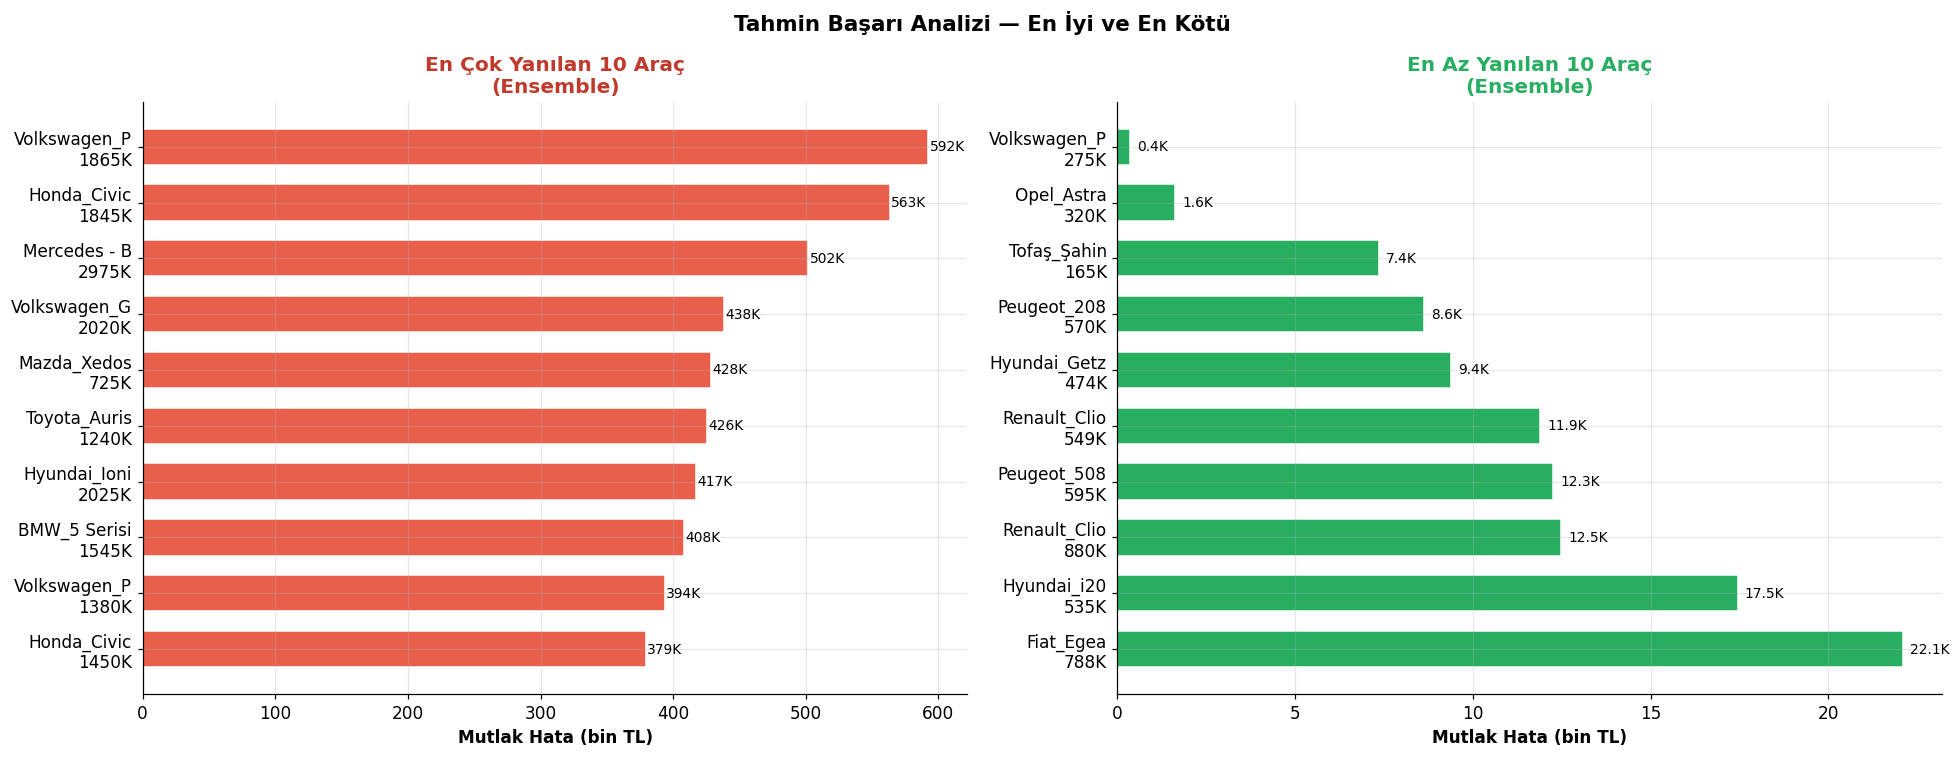

In [85]:
TOP_N = 10
en_kotu   = sonuclar.nlargest(TOP_N, 'hata_ens').copy()
en_iyi    = sonuclar.nsmallest(TOP_N, 'hata_ens').copy()

# Marka bilgisini ekle
en_kotu['marka']  = df_yeni.loc[en_kotu.index, 'marka'].values
en_iyi['marka']   = df_yeni.loc[en_iyi.index,  'marka'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# En Kötü
etiketler_kotu = [
    f"{row['marka'][:12]}\n{row['gercek_fiyat']/1000:.0f}K"
    for _, row in en_kotu.iterrows()
]
barlar = ax1.barh(etiketler_kotu, en_kotu['hata_ens'] / 1000,
                  color=RENK_ENS, edgecolor='white', height=0.65)
ax1.set_xlabel('Mutlak Hata (bin TL)', fontweight='bold')
ax1.set_title(f'En Çok Yanılan {TOP_N} Araç\n(Ensemble)', fontweight='bold', color='#C0392B')
for bar, val in zip(barlar, en_kotu['hata_ens']):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{val/1000:.0f}K', va='center', fontsize=9)
ax1.invert_yaxis()

# En İyi
etiketler_iyi = [
    f"{row['marka'][:12]}\n{row['gercek_fiyat']/1000:.0f}K"
    for _, row in en_iyi.iterrows()
]
barlar2 = ax2.barh(etiketler_iyi, en_iyi['hata_ens'] / 1000,
                   color='#27AE60', edgecolor='white', height=0.65)
ax2.set_xlabel('Mutlak Hata (bin TL)', fontweight='bold')
ax2.set_title(f'En Az Yanılan {TOP_N} Araç\n(Ensemble)', fontweight='bold', color='#27AE60')
for bar, val in zip(barlar2, en_iyi['hata_ens']):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val/1000:.1f}K', va='center', fontsize=9)
ax2.invert_yaxis()

fig.suptitle('Tahmin Başarı Analizi — En İyi ve En Kötü', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik9_iyi_kotu.png', dpi=130, bbox_inches='tight')
plt.show()

## 15. Grafik 10 — Residual Plot (Hata Artığı Analizi)

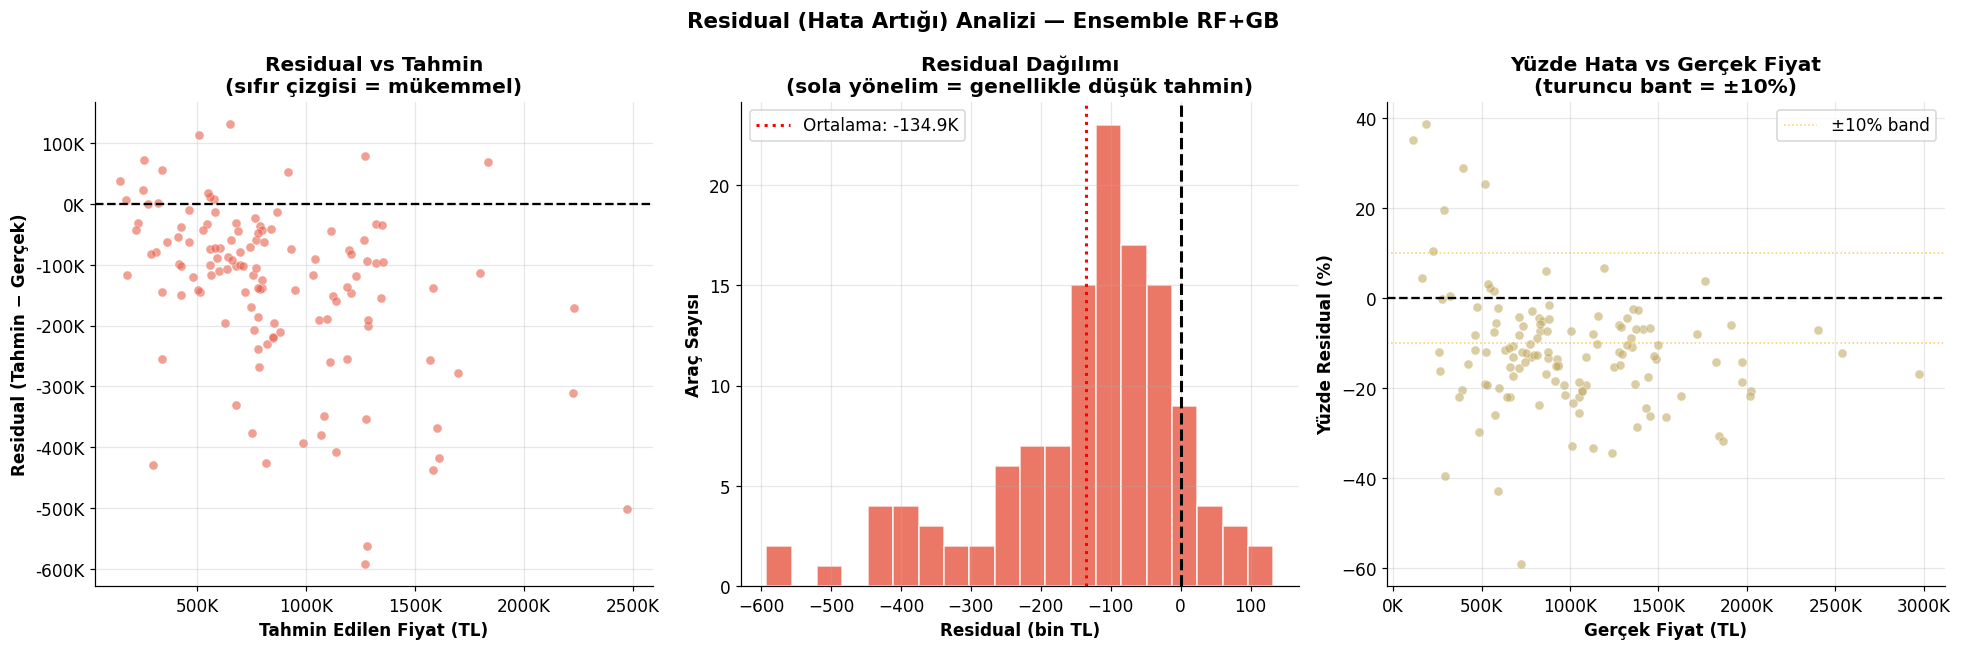

In [87]:
# Residual = Tahmin - Gerçek (pozitif = aşırı tahmin, negatif = düşük tahmin)
residual_ens = pred_ens - y_yeni.values
residual_pct = residual_ens / y_yeni.values * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Residual vs Tahmin
axes[0].scatter(pred_ens, residual_ens, alpha=0.6, s=35, color=RENK_ENS, edgecolors='white', linewidths=0.4)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Tahmin Edilen Fiyat (TL)', fontweight='bold')
axes[0].set_ylabel('Residual (Tahmin − Gerçek)', fontweight='bold')
axes[0].set_title('Residual vs Tahmin\n(sıfır çizgisi = mükemmel)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))

# 2) Residual histogram
axes[1].hist(residual_ens / 1000, bins=20, color=RENK_ENS, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].axvline(np.mean(residual_ens)/1000, color='red', linestyle=':', linewidth=2,
               label=f'Ortalama: {np.mean(residual_ens)/1000:.1f}K')
axes[1].set_xlabel('Residual (bin TL)', fontweight='bold')
axes[1].set_ylabel('Araç Sayısı', fontweight='bold')
axes[1].set_title('Residual Dağılımı\n(sola yönelim = genellikle düşük tahmin)', fontweight='bold')
axes[1].legend()

# 3) Yüzde residual
axes[2].scatter(y_yeni.values, residual_pct, alpha=0.6, s=35, color=RENK_GB, edgecolors='white', linewidths=0.4)
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[2].axhline( 10, color='orange', linestyle=':', linewidth=1, alpha=0.6)
axes[2].axhline(-10, color='orange', linestyle=':', linewidth=1, alpha=0.6, label='±10% band')
axes[2].set_xlabel('Gerçek Fiyat (TL)', fontweight='bold')
axes[2].set_ylabel('Yüzde Residual (%)', fontweight='bold')
axes[2].set_title('Yüzde Hata vs Gerçek Fiyat\n(turuncu bant = ±10%)', fontweight='bold')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
axes[2].legend()

fig.suptitle('Residual (Hata Artığı) Analizi — Ensemble RF+GB', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik10_residual.png', dpi=130, bbox_inches='tight')
plt.show()

## 16. Özet Tablo — Tüm Metrikler

In [90]:
ozet = pd.DataFrame([
    {
        'Model': isim,
        'R²': f'{r2:.4f}',
        'MAE (TL)': f'{mae:,.0f}',
        'RMSE (TL)': f'{rmse:,.0f}',
        'MAPE (%)': f'{mape:.2f}',
        'Medyan Hata (TL)': f'{medyan_h:,.0f}',
    }
    for isim, (r2, mae, rmse, mape, medyan_h) in [
        ('Random Forest',     (r2_score(y_yeni, pred_rf),  mean_absolute_error(y_yeni, pred_rf),
                               np.sqrt(mean_squared_error(y_yeni, pred_rf)),
                               np.mean(np.abs((y_yeni.values - pred_rf)  / y_yeni.values))*100,
                               np.median(np.abs(y_yeni.values - pred_rf)))),
        ('Gradient Boosting', (r2_score(y_yeni, pred_gb),  mean_absolute_error(y_yeni, pred_gb),
                               np.sqrt(mean_squared_error(y_yeni, pred_gb)),
                               np.mean(np.abs((y_yeni.values - pred_gb)  / y_yeni.values))*100,
                               np.median(np.abs(y_yeni.values - pred_gb)))),
        ('Ensemble RF+GB ★',  (r2_score(y_yeni, pred_ens), mean_absolute_error(y_yeni, pred_ens),
                               np.sqrt(mean_squared_error(y_yeni, pred_ens)),
                               np.mean(np.abs((y_yeni.values - pred_ens) / y_yeni.values))*100,
                               np.median(np.abs(y_yeni.values - pred_ens)))),
    ]
])

print('=' * 75)
print('FİNAL PERFORMANS ÖZETİ — YENİ VERİ (133 ARAÇ)')
print('=' * 75)
print(ozet.to_string(index=False))
print('=' * 75)
ozet

FİNAL PERFORMANS ÖZETİ — YENİ VERİ (133 ARAÇ)
            Model     R² MAE (TL) RMSE (TL) MAPE (%) Medyan Hata (TL)
    Random Forest 0.8563  149,444   195,362    15.28          116,101
Gradient Boosting 0.8642  143,114   189,919    14.70          102,029
 Ensemble RF+GB ★ 0.8623  145,754   191,262    14.85          108,072


,Model,R²,MAE (TL),RMSE (TL),MAPE (%),Medyan Hata (TL)
0,Random Forest,0.8563,"149,444","195,362",15.28,"116,101"
1,Gradient Boosting,0.8642,"143,114","189,919",14.70,"102,029"
2,Ensemble RF+GB ★,0.8623,"145,754","191,262",14.85,"108,072"


## 17. Sonuçları Excel'e Kaydet

In [93]:
# Tahmin sonuçlarını ayrıntılı kaydet
df_kayit = df_yeni[['marka', 'model', 'yas', 'kilometre', 'fiyat']].copy()
df_kayit['tahmin_rf']       = pred_rf.round().astype(int)
df_kayit['tahmin_gb']       = pred_gb.round().astype(int)
df_kayit['tahmin_ensemble'] = pred_ens.round().astype(int)
df_kayit['hata_ensemble']   = np.abs(df_kayit['fiyat'] - df_kayit['tahmin_ensemble'])
df_kayit['hata_pct']        = (df_kayit['hata_ensemble'] / df_kayit['fiyat'] * 100).round(1)

df_kayit.to_excel('tahmin_sonuclari.xlsx', index=False)
print('✅ tahmin_sonuclari.xlsx kaydedildi')

# Özet metrikler
ozet.to_excel('model_metrikleri.xlsx', index=False)
print('✅ model_metrikleri.xlsx kaydedildi')

print(f'\nToplam {len(df_kayit)} araç için tahmin yapıldı.')
print(f"Ensemble MAE: {df_kayit['hata_ensemble'].mean():,.0f} TL")
print(f"Ensemble MAPE: {df_kayit['hata_pct'].mean():.2f}%")

✅ tahmin_sonuclari.xlsx kaydedildi
✅ model_metrikleri.xlsx kaydedildi

Toplam 126 araç için tahmin yapıldı.
Ensemble MAE: 145,754 TL
Ensemble MAPE: 14.85%
